#Convolutional Neural Network (CNN)
A Convolutional Neural Network (CNN) is a deep learning model that automatically extracts features from images using convolution operations and then uses those features for tasks such as image classification, object detection, and image recognition.




Unlike a normal Artificial Neural Network (ANN), CNN does not require us to manually tell it what features to look for. It learns those features by itself during training.


output size = [(N-F+2P)/S] +1
-
WHERE, N  = INPUT SIZE (height or width)
- F = FILTER(KERNEL) SIZE
- P = PADDING
- S = STRIDE

Why Do We Need CNN?

Suppose you want a computer to identify whether an image contains a cat or a dog.

A traditional ANN would treat every pixel independently, making it inefficient for images.

A CNN:

- Detects edges
- Detects shapes
- Detects patterns
- Recognizes objects

without manually telling it what features to look for.

Real-Life Example

Suppose the input image is

🐱 Cat Image

CNN processes the image like this:

Image
   │
   ▼
Detect Edges
   │
   ▼
Detect Eyes
   │
   ▼
Detect Nose
   │
   ▼
Detect Ears
   │
   ▼
Recognize Cat

Input Image
      │
      ▼
Convolution Layer
      │
      ▼
Activation (ReLU)
      │
      ▼
Pooling Layer
      │
      ▼
Convolution
      │
      ▼
ReLU
      │
      ▼
Pooling
      │
      ▼
Flatten
      │
      ▼
Fully Connected Layer
      │
      ▼
Output Layer

Pooling in Convolutional Neural Networks (CNN)

Pooling is a layer in a Convolutional Neural Network (CNN) that reduces the size (width and height) of feature maps while preserving the most important information.

It is also called a Downsampling Layer because it decreases the dimensions of the data.

Why Do We Need Pooling?

Imagine an image of size:

200 × 200 pixels

Processing every pixel is computationally expensive.

Pooling reduces the size.

How Does Pooling Work?

Pooling divides the feature map into small regions (commonly 2 × 2) and summarizes each region into a single value.

For example, a 2 × 2 Max Pooling window:

1   3
2   5

The output is:

5

because 5 is the largest value.

# The MNIST dataset contains:

- 70,000 grayscale images
- Image size: 28 × 28 pixels
- Digits: 0 to 9
- Training images: 60,000
- Test images: 10,000

- Each image has the shape:

- 28 × 28 × 1

- where:

- Height = 28
- Width = 28
- Channel = 1 (grayscale)

In [43]:
import tensorflow as tf

In [44]:
print(tf.__version__)

2.20.0


In [45]:
from tensorflow.keras.datasets import mnist

In [62]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [63]:
print(type(x_train))

<class 'numpy.ndarray'>


Step 4: Display the First Image

In [64]:
print(x_train.shape)

(60000, 28, 28)


In [55]:
print(y_train.shape)

(60000,)


In [56]:
print(x_test.shape)
print(y_test.shape)

(10000, 28, 28)
(10000,)


In [65]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [59]:
print(y_train[0])

5


In [66]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

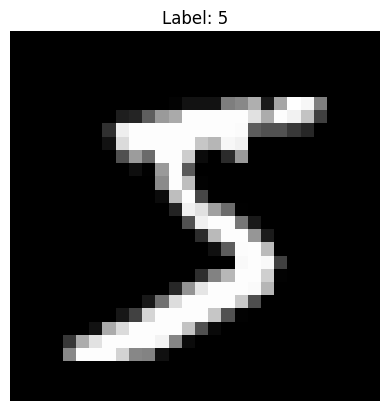

In [67]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

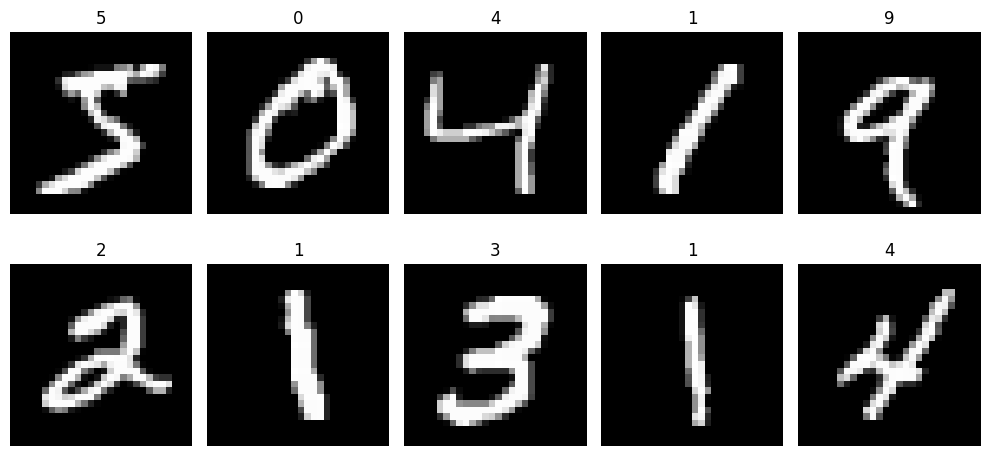

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [69]:
# Normalize Images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [73]:
print(x_train.shape)

(60000, 28, 28)


In [74]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [75]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [78]:
from tensorflow.keras.models import Sequential

In [ ]:
# fully conection (dense layer)
# (no of input *no of ouptup0 + no of bias)
# convolution layer
# (filer width*filter hegith *input depth*number of fileter ) +no of bias

In [79]:
model = Sequential()

In [80]:
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.add(MaxPooling2D(pool_size=(2,2)))

In [83]:
model.add(Dense(128, activation='relu'))

In [84]:
model.add(Dense(10, activation='softmax'))

In [85]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6, 6, 128)      │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6, 6, 10)       │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,834 (22.79 KB)

 Trainable params: 5,834 (22.79 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model = Sequential()

model.add(Conv2D(32,
                 (3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

model.add(MaxPooling2D((2,2)))

# ⭐ This layer was missing
model.add(Flatten())

model.add(Dense(128,
                activation='relu'))

model.add(Dense(10,
                activation='softmax'))

In [91]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [93]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.9492 - loss: 0.1709 - val_accuracy: 0.9778 - val_loss: 0.0726
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9818 - loss: 0.0578 - val_accuracy: 0.9833 - val_loss: 0.0591
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 0.9822 - val_loss: 0.0685
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9927 - loss: 0.0235 - val_accuracy: 0.9828 - val_loss: 0.0647
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9841 - val_loss: 0.0617
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9965 - loss: 0.0111 - val_accuracy: 0.9867 - val_loss: 0.0542
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9970 - loss: 0.0089 - val_accuracy: 0.9857 - val_loss: 0.0603
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9977 -

In [94]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9858 - loss: 0.0602


In [95]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.06015893071889877
Test Accuracy: 0.98580002784729


In [96]:
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Test Accuracy: 98.58%


In [97]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


Interview Questions
- Why are convolution layers placed before - dense layers?
- Because they extract meaningful features from - raw images before classification.
- Why is ReLU applied after convolution?
- To introduce non-linearity and improve - learning by removing negative activations.
- Why do we use pooling?
- To reduce computation, memory usage, and - overfitting while retaining important - information.
- Why is Flatten necessary?
- Because Dense layers expect a one-dimensional - input vector.
- What is the difference between a feature map - and a filter?
- A filter is the small matrix that scans the - image. A feature map is the output generated - after applying that filter.

why not multiplying in pooling

That's an excellent question. Many beginners confuse pooling with convolution because both use a small window (such as 2×2 or 3×3), but they perform different operations.

Short Answer

Pooling does not multiply values because its purpose is to reduce the size of the feature map, not to learn features.

In [99]:
print(predictions.shape)

(10000, 10)


In [100]:
print(predictions[0])

[3.0278385e-15 7.5343310e-15 1.7145018e-13 1.3671919e-12 3.4686717e-20
 9.5809425e-17 7.0059406e-22 9.9999994e-01 4.3356754e-14 1.7050348e-13]


In [101]:
import numpy as np

predicted_label = np.argmax(predictions[0])

print(predicted_label)

7


In [102]:
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", y_test[0])

Predicted: 7
Actual: 7


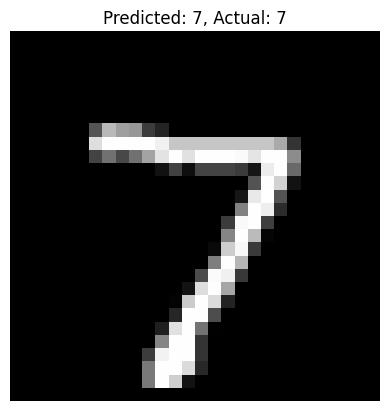

In [103]:
import matplotlib.pyplot as plt

plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted: {np.argmax(predictions[0])}, Actual: {y_test[0]}")
plt.axis("off")
plt.show()

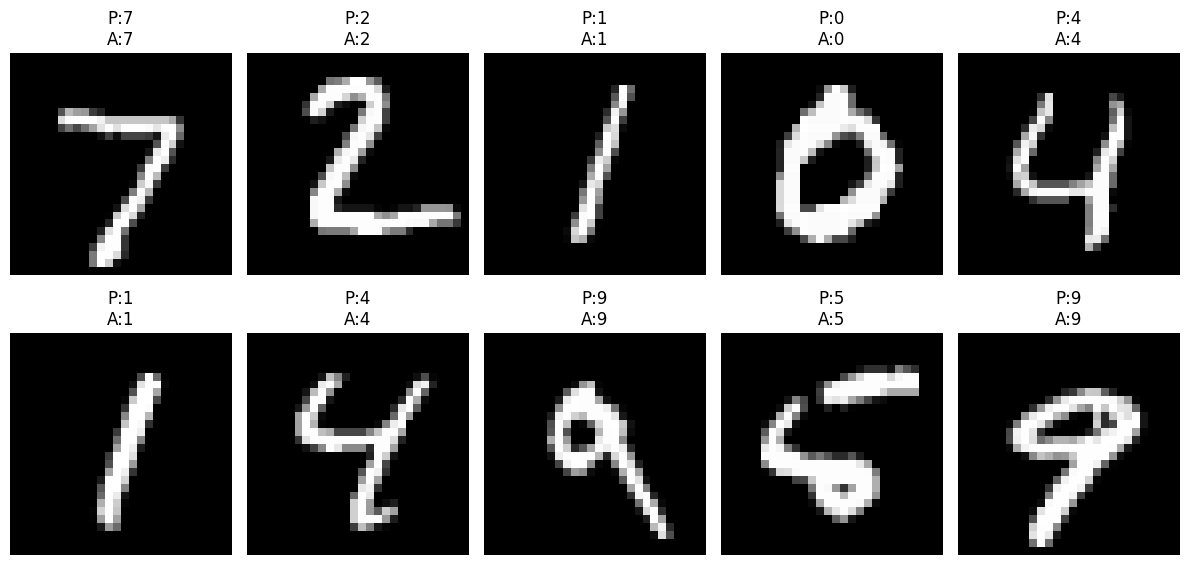

In [105]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"P:{np.argmax(predictions[i])}\nA:{y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [106]:
incorrect = np.where(np.argmax(predictions, axis=1) != y_test)[0]

print("Number of incorrect predictions:", len(incorrect))

Number of incorrect predictions: 142


In [107]:
np.argmax(predictions, axis=1)

array([7, 2, 1, ..., 4, 5, 6])

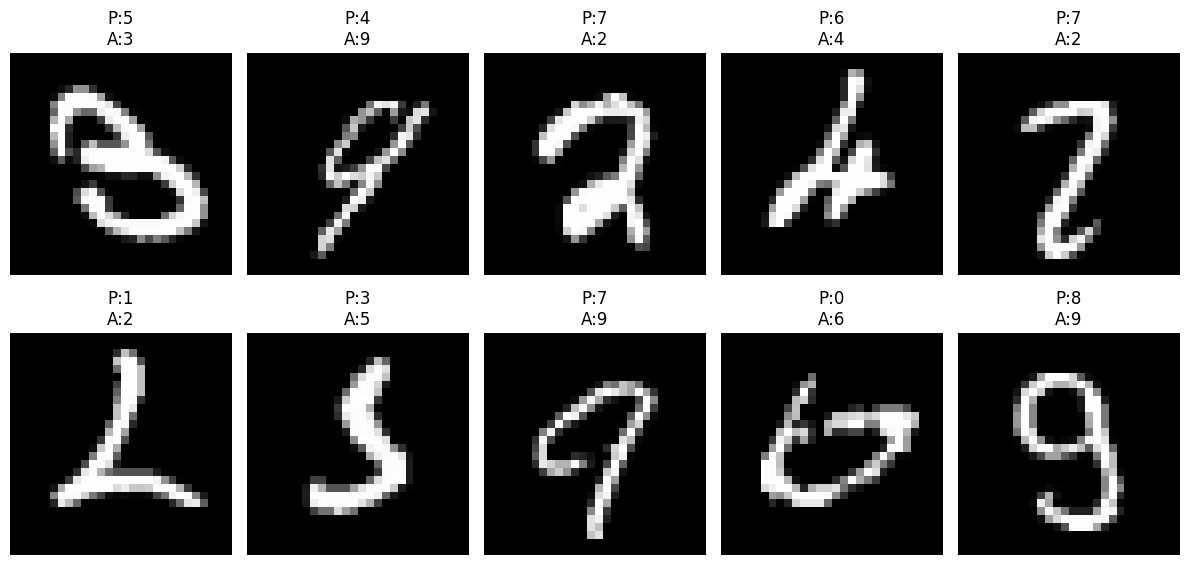

In [108]:
plt.figure(figsize=(12,6))

for i in range(10):
    idx = incorrect[i]

    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"P:{np.argmax(predictions[idx])}\nA:{y_test[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [109]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [112]:
y_pred = np.argmax(predictions, axis=1)

In [113]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 975    0    1    0    0    1    2    1    0    0]
 [   0 1128    1    1    2    0    1    0    2    0]
 [   1    4 1015    1    1    0    2    7    1    0]
 [   0    1    3  995    0    6    0    3    2    0]
 [   0    0    0    0  979    0    2    0    0    1]
 [   2    0    0    5    0  882    2    0    1    0]
 [   8    2    0    0    1    4  940    0    3    0]
 [   0    1    6    1    0    0    0 1016    1    3]
 [   4    0    4    1    4    1    1    2  955    2]
 [   1    1    0    1   14    3    0   13    3  973]]


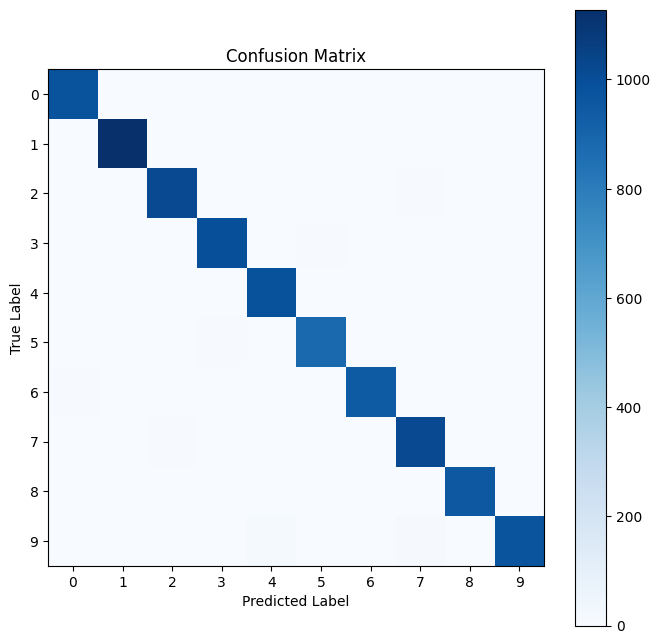

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()